# VulnScope: CVE data quality and temporal EDA

This notebook examines the canonical CVE dataset, reproduces the historical completeness analysis, and identifies reporting changes that could affect temporal modeling. It uses publication year—not the year embedded in a CVE ID—for all temporal comparisons.

Important: completeness describes what is present in the current CVE record. It does not prove that a field was available on the original publication date.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed"
PARQUET_PATH = DATA_DIR / "cves_clean.parquet"
LEGACY_COMPLETENESS_PATH = DATA_DIR / "cve_completeness_by_year.csv"

print(f"Project root: {ROOT}")
print(f"Dataset: {PARQUET_PATH}")

Project root: /Users/sharanyamishra/Desktop/PersonalProject/VulnScope
Dataset: /Users/sharanyamishra/Desktop/PersonalProject/VulnScope/data/processed/cves_clean.parquet


In [2]:
df = pd.read_parquet(PARQUET_PATH)
legacy_completeness = pd.read_csv(LEGACY_COMPLETENESS_PATH)

print(f"Canonical rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Publication range: {int(df.publication_year.min())}–{int(df.publication_year.max())}")
display(df.head(3))

Canonical rows: 378,496
Columns: 69
Publication range: 1999–2026


,cve_id,state,date_reserved,date_published,date_updated,cna,title,description,cwe_ids,primary_cwe,cwe_count,vendors,primary_vendor,vendor_count,products,product_count,affected_version_count,unaffected_version_count,cvss_score,cvss_version,severity,attack_vector,attack_complexity,privileges_required,user_interaction,scope,confidentiality_impact,integrity_impact,availability_impact,cvss_source,cvss_provider_updated,has_cisa_adp,ssvc_exploitation,ssvc_automatable,ssvc_technical_impact,ssvc_timestamp,has_solution,solution,discovery_type,has_legacy_v4,ref_vendor_advisory,ref_third_party_advisory,ref_patch,ref_exploit,ref_vdb,ref_issue_tracking,ref_mailing_list,ref_government,ref_release_notes,ref_mitigation,ref_technical_description,reference_count,tag_remote,tag_code_execution,tag_denial_of_service,tag_authenticated,tag_unauthenticated,tag_sql_injection,tag_xss,tag_buffer_overflow,tag_privilege_escalation,tag_use_after_free,tag_path_traversal,tag_command_injection,tag_information_disclosure,tag_memory_corruption,publication_year,days_reserved_to_published,days_published_to_updated
0,CVE-2013-2824,PUBLISHED,2013-04-11 00:00:00+00:00,2014-02-26 11:00:00+00:00,2024-08-06 15:52:20.055000+00:00,icscert,None,Schneider Electric StruxureWare SCADA Expert V...,,None,0,,None,0,,0,1,0,NaN,None,None,None,None,None,None,None,None,None,None,None,NaT,False,None,None,None,NaT,False,None,None,True,0,0,0,0,0,0,0,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,2014.0,321.458333,3814.203010
1,CVE-2013-2127,PUBLISHED,2013-02-19 00:00:00+00:00,2013-08-14 15:00:00+00:00,2024-09-16 17:59:00.243000+00:00,redhat,None,Buffer overflow in the exposure correction cod...,,None,0,,None,0,,0,1,0,NaN,None,None,None,None,None,None,None,None,None,None,None,NaT,False,None,None,None,NaT,False,None,None,True,0,1,0,0,0,0,1,0,0,0,0,4,0,1,1,0,0,0,0,1,0,0,0,0,0,0,2013.0,176.625000,4051.124308
2,CVE-2013-2577,PUBLISHED,2013-03-15 00:00:00+00:00,2013-08-09 21:00:00+00:00,2024-08-06 15:44:32.301000+00:00,mitre,None,Buffer overflow in XnView before 2.04 allows r...,,None,0,,None,0,,0,1,0,NaN,None,None,None,None,None,None,None,None,None,None,None,NaT,False,None,None,None,NaT,False,None,None,True,0,1,0,1,3,0,1,0,0,0,0,8,1,1,0,0,0,0,0,1,0,0,0,0,0,0,2013.0,147.875000,4014.780929


## 1. Structural validation

These checks look for duplicate identifiers, missing publication dates, impossible timestamp ordering, and records outside the intended publication range. Negative intervals are retained for investigation rather than silently removed.

In [3]:
quality_checks = pd.Series({
    "rows": len(df),
    "duplicate_cve_ids": int(df.cve_id.duplicated().sum()),
    "missing_cve_ids": int(df.cve_id.isna().sum()),
    "missing_publication_dates": int(df.date_published.isna().sum()),
    "updated_before_published": int((df.date_updated < df.date_published).sum()),
    "reserved_after_published": int((df.date_reserved > df.date_published).sum()),
    "description_control_characters": int(
        df.description.fillna("").str.contains(r"[\r\n\t]").sum()
    ),
}, name="value")
display(quality_checks.to_frame())

,value
rows,378496
duplicate_cve_ids,0
missing_cve_ids,0
missing_publication_dates,2
updated_before_published,0
reserved_after_published,237
description_control_characters,0


## 2. Recomputed completeness

The old completeness CSV was generated by an earlier extractor. In particular, its CWE check searched recursively across the complete JSON record. The canonical dataset's `primary_cwe` is restricted to the CNA problem-type structure. Both measurements are useful, but they answer different questions and should not be treated as interchangeable.

In [4]:
presence = pd.DataFrame({
    "publication_year": df.publication_year,
    "description": df.description.notna(),
    "vendor": df.primary_vendor.notna(),
    "product": df.products.fillna("").ne(""),
    "cna_cwe": df.primary_cwe.notna(),
    "cvss": df.cvss_score.notna(),
    "attack_vector": df.attack_vector.notna(),
    "cisa_adp": df.has_cisa_adp.fillna(False),
    "solution": df.has_solution.fillna(False),
    "legacy_v4": df.has_legacy_v4.fillna(False),
})

yearly_completeness = (
    presence.groupby("publication_year")
    .mean()
    .mul(100)
    .round(1)
)
yearly_counts = df.groupby("publication_year").size().rename("total_cves")
yearly_summary = yearly_counts.to_frame().join(yearly_completeness)
display(yearly_summary.loc[2015:2026])

,total_cves,description,vendor,product,cna_cwe,cvss,attack_vector,cisa_adp,solution,legacy_v4
publication_year,,,,,,,,,,
2015.0,6494,100.0,0.3,0.3,0.2,1.2,1.0,1.0,0.2,96.2
2016.0,6457,100.0,1.6,4.5,0.1,1.5,1.5,8.3,0.0,95.0
2017.0,14642,100.0,34.1,44.7,5.2,2.9,2.9,7.9,0.0,97.8
2018.0,16510,100.0,47.4,52.3,14.6,10.6,10.5,8.6,0.9,98.1
2019.0,17308,100.0,44.5,54.2,12.7,15.2,14.3,9.0,1.3,96.2
2020.0,18363,100.0,45.9,60.6,19.2,33.1,29.9,9.9,2.5,94.2
2021.0,20177,100.0,49.9,67.8,34.4,41.5,37.1,12.2,5.0,91.4
2022.0,24998,100.0,53.7,68.8,41.7,59.1,53.6,41.9,5.5,65.9
2023.0,28847,100.0,69.6,78.2,57.1,80.3,65.4,83.6,9.6,0.0


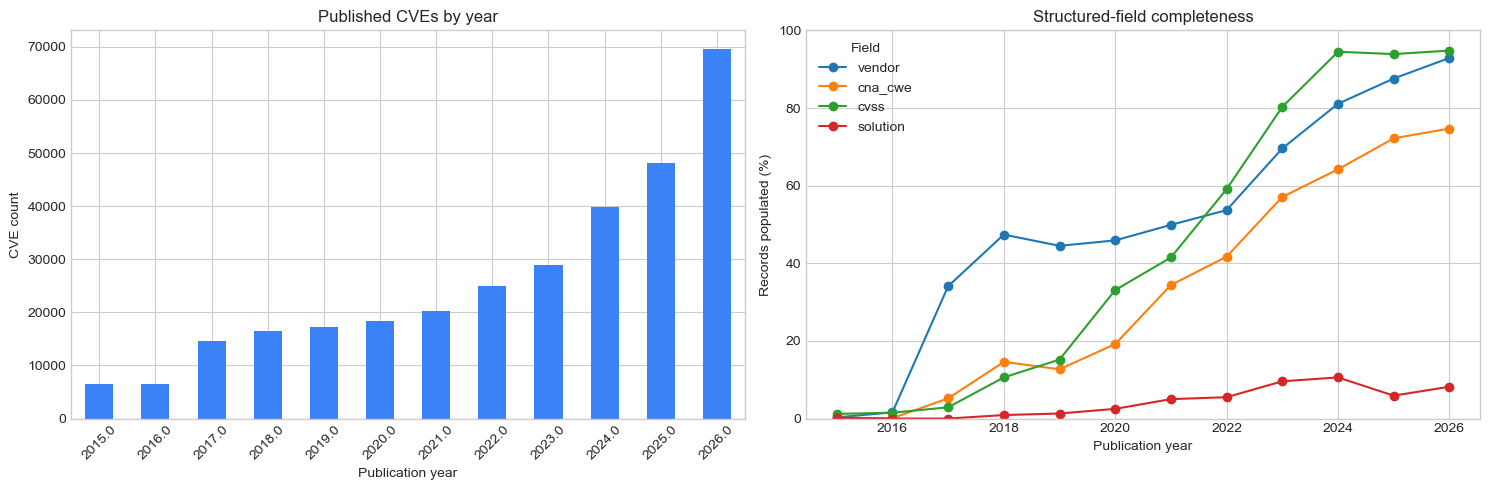

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

yearly_counts.loc[2015:2026].plot(kind="bar", ax=axes[0], color="#3b82f6")
axes[0].set_title("Published CVEs by year")
axes[0].set_xlabel("Publication year")
axes[0].set_ylabel("CVE count")
axes[0].tick_params(axis="x", rotation=45)

yearly_completeness.loc[2015:2026, ["vendor", "cna_cwe", "cvss", "solution"]].plot(
    ax=axes[1], marker="o"
)
axes[1].set_title("Structured-field completeness")
axes[1].set_xlabel("Publication year")
axes[1].set_ylabel("Records populated (%)")
axes[1].set_ylim(0, 100)
axes[1].legend(title="Field")
plt.tight_layout()
plt.show()

### Interpretation

- Vendor and product coverage is extremely low in legacy records and rises sharply in recent years. This is primarily a structured-schema availability issue, not evidence that old vulnerabilities had no vendors.
- Explicit solution objects remain sparse and source-dependent. A missing structured solution does not mean that no patch or remediation exists.
- CVE volume rises strongly, especially after 2022. Counts can reflect CNA participation, bulk publication, and backlog processing in addition to changes in vulnerability incidence.
- CNA-structured CWE coverage improves over time. The older recursive CWE measurement is higher because it can include later enrichment containers.

,legacy_anywhere_cwe_pct,canonical_cna_cwe_pct
publication_year,,
2015,1.0,0.2
2016,1.0,0.1
2017,6.4,5.2
2018,15.4,14.6
2019,13.8,12.7
2020,20.4,19.2
2021,35.7,34.4
2022,56.5,41.7
2023,75.4,57.1


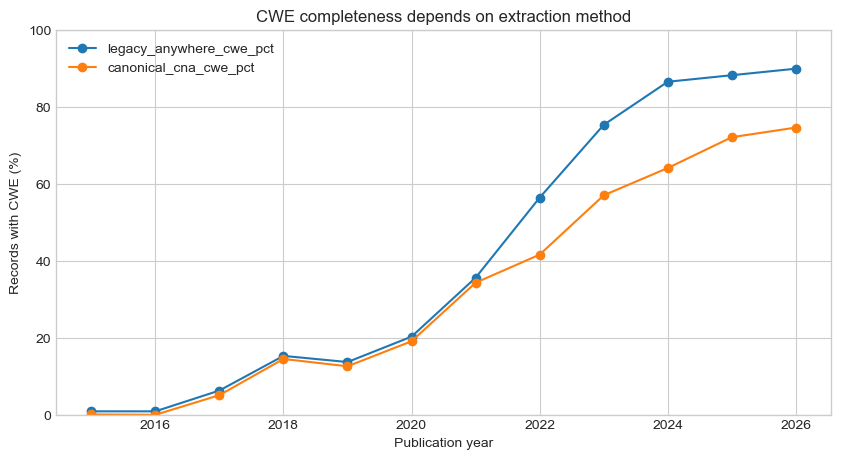

In [6]:
legacy_cwe = legacy_completeness.set_index("publication_year")["has_cwe"].rename("legacy_anywhere_cwe_pct")
cna_cwe = yearly_completeness["cna_cwe"].rename("canonical_cna_cwe_pct")
cwe_method_comparison = pd.concat([legacy_cwe, cna_cwe], axis=1).loc[2015:2026]
display(cwe_method_comparison)

cwe_method_comparison.plot(figsize=(10, 5), marker="o")
plt.title("CWE completeness depends on extraction method")
plt.xlabel("Publication year")
plt.ylabel("Records with CWE (%)")
plt.ylim(0, 100)
plt.show()

## 3. Reporting-regime changes

CISA enrichment, CVSS completeness, and legacy-record prevalence change abruptly across years. These are strong warning signs for temporal modeling: a model can learn the reporting era or data provider rather than exploitation risk.

,cvss,attack_vector,cisa_adp,legacy_v4
publication_year,,,,
2015.0,1.2,1.0,1.0,96.2
2016.0,1.5,1.5,8.3,95.0
2017.0,2.9,2.9,7.9,97.8
2018.0,10.6,10.5,8.6,98.1
2019.0,15.2,14.3,9.0,96.2
2020.0,33.1,29.9,9.9,94.2
2021.0,41.5,37.1,12.2,91.4
2022.0,59.1,53.6,41.9,65.9
2023.0,80.3,65.4,83.6,0.0


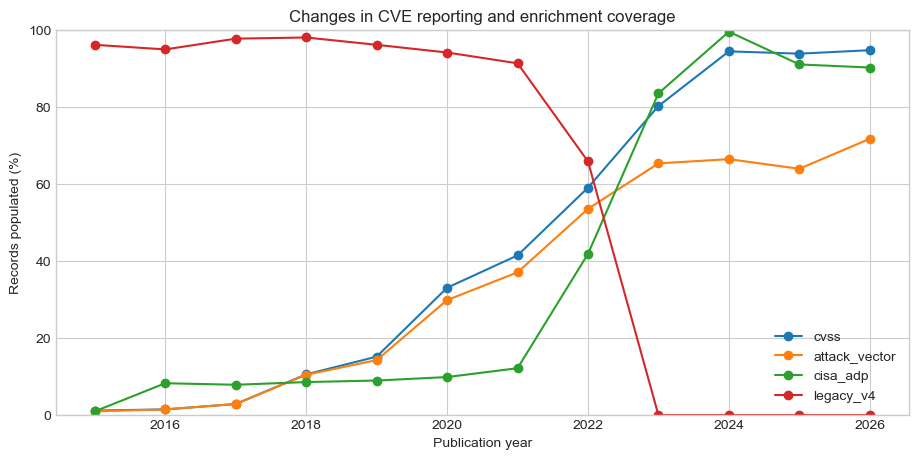

In [7]:
reporting_regime = yearly_completeness.loc[2015:2026, [
    "cvss", "attack_vector", "cisa_adp", "legacy_v4"
]]
display(reporting_regime)

reporting_regime.plot(figsize=(11, 5), marker="o")
plt.title("Changes in CVE reporting and enrichment coverage")
plt.xlabel("Publication year")
plt.ylabel("Records populated (%)")
plt.ylim(0, 100)
plt.show()

cvss_version,2.0,3.0,3.1,4.0
publication_year,,,,
2020.0,0.0,43.8,56.1,0.1
2021.0,0.0,19.6,80.3,0.1
2022.0,0.0,13.5,86.3,0.2
2023.0,0.0,5.0,94.8,0.2
2024.0,0.0,5.1,85.5,9.5
2025.0,0.0,2.2,70.3,27.5
2026.0,0.0,0.7,66.3,33.0


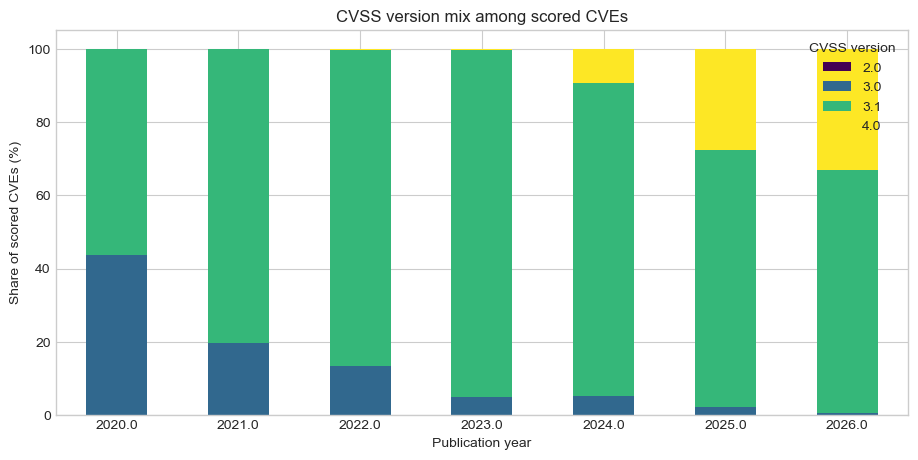

In [8]:
modern = df[df.publication_year.between(2020, 2026)].copy()
cvss_versions = (
    pd.crosstab(modern.publication_year, modern.cvss_version, normalize="index")
    .mul(100)
    .round(1)
)
display(cvss_versions)

cvss_versions.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="viridis")
plt.title("CVSS version mix among scored CVEs")
plt.xlabel("Publication year")
plt.ylabel("Share of scored CVEs (%)")
plt.xticks(rotation=0)
plt.legend(title="CVSS version")
plt.show()

## 4. Publication timing and CVE ID year

A CVE ID's year is an assignment/reservation convention, not necessarily its publication year. Temporal splits must continue to use `date_published`.

In [9]:
modern["cve_id_year"] = pd.to_numeric(
    modern.cve_id.str.split("-").str[1], errors="coerce"
)
modern["older_id_year"] = modern.cve_id_year < modern.publication_year

timing_summary = modern.groupby("publication_year").agg(
    cves=("cve_id", "size"),
    older_id_year_pct=("older_id_year", lambda s: 100 * s.mean()),
    median_reservation_to_publication_days=("days_reserved_to_published", "median"),
    median_references=("reference_count", "median"),
).round(1)
display(timing_summary)

,cves,older_id_year_pct,median_reservation_to_publication_days,median_references
publication_year,,,,
2020.0,18363,22.2,99.7,1.0
2021.0,20177,19.5,91.8,2.0
2022.0,24998,20.8,42.0,1.0
2023.0,28847,19.0,36.0,1.0
2024.0,39924,18.2,21.0,2.0
2025.0,48153,20.4,18.0,2.0
2026.0,69615,10.6,13.2,2.0


## 5. CNA composition

The mix of assigning organizations changes over time. Because CNAs differ in schema usage, wording, CVSS practices, and solution reporting, CNA identity can act as both a useful feature and a source of dataset shift.

In [10]:
top_cnas = (
    modern.groupby("publication_year")["cna"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("share_pct")
    .reset_index()
    .groupby("publication_year")
    .head(5)
)
display(top_cnas)

,publication_year,cna,share_pct
0,2020.0,mitre,39.323640
1,2020.0,microsoft,6.872515
2,2020.0,oracle,4.416490
3,2020.0,redhat,3.087731
4,2020.0,ibm,3.076839
123,2021.0,mitre,32.081082
124,2021.0,GitHub_M,5.278287
125,2021.0,microsoft,4.316796
126,2021.0,WPScan,3.702235
127,2021.0,ibm,2.998464


## 6. Outlier review

Outliers are review candidates, not automatic deletion candidates. Large vendor/product lists may describe ecosystem-wide issues, while extreme timing values can reflect reservations, rejections, or migrated historical records.

In [11]:
outlier_columns = [
    "cve_id", "publication_year", "primary_vendor", "vendor_count",
    "product_count", "affected_version_count", "reference_count",
    "days_reserved_to_published"
]

print("Largest product counts")
display(df.nlargest(10, "product_count")[outlier_columns])

print("Largest reference counts")
display(df.nlargest(10, "reference_count")[outlier_columns])

print("Longest reservation-to-publication intervals")
display(df.nlargest(10, "days_reserved_to_published")[outlier_columns])

Largest product counts


,cve_id,publication_year,primary_vendor,vendor_count,product_count,affected_version_count,reference_count,days_reserved_to_published
275665,CVE-2026-5667,2026.0,Mitsubishi Electric Corporation,1,2480,2480,2,72.113218
98404,CVE-2024-51984,2025.0,"Brother Industries, Ltd",5,743,744,10,232.589566
89838,CVE-2024-8105,2024.0,Acer,10,741,743,8,3.975740
98467,CVE-2024-51983,2025.0,"Brother Industries, Ltd",5,712,713,9,232.588631
97994,CVE-2024-51980,2025.0,"Brother Industries, Ltd",5,707,708,10,232.585254
97967,CVE-2024-51981,2025.0,"Brother Industries, Ltd",5,701,702,10,232.586069
97990,CVE-2024-51979,2025.0,"Brother Industries, Ltd",4,636,637,9,232.584146
35300,CVE-2022-4974,2024.0,5starplugins,388,620,620,6,0.521850
97974,CVE-2024-51978,2025.0,"Brother Industries, Ltd",3,605,605,10,232.582102
98582,CVE-2024-51977,2025.0,"Brother Industries, Ltd",5,451,452,11,232.580532


Largest reference counts


,cve_id,publication_year,primary_vendor,vendor_count,product_count,affected_version_count,reference_count,days_reserved_to_published
191724,CVE-2009-3555,2009.0,None,0,0,1,310,35.708333
12512,CVE-2014-0224,2014.0,None,0,0,1,305,184.875000
8929,CVE-2014-3566,2014.0,None,0,0,1,265,154.000000
158696,CVE-2015-4000,2015.0,None,0,0,1,219,6.000000
179327,CVE-2006-4339,2006.0,None,0,0,1,209,12.708333
172514,CVE-2008-1447,2008.0,None,0,0,1,200,109.958333
7237,CVE-2014-6271,2014.0,None,0,0,1,177,15.750000
8292,CVE-2014-7169,2014.0,None,0,0,1,166,1.041667
9310,CVE-2014-3470,2014.0,None,0,0,1,151,22.875000
9189,CVE-2014-3200,2014.0,None,0,0,1,150,158.416667


Longest reservation-to-publication intervals


,cve_id,publication_year,primary_vendor,vendor_count,product_count,affected_version_count,reference_count,days_reserved_to_published
367571,CVE-2005-2354,2019.0,None,0,1,1,3,5219.806898
367754,CVE-2005-2352,2019.0,gs-gpl,1,1,1,2,5215.862234
367923,CVE-2005-2351,2019.0,mutt,1,1,1,2,5215.782847
367984,CVE-2005-2350,2019.0,websieve,1,1,2,2,5215.731273
367603,CVE-2005-2349,2019.0,None,0,0,1,2,5211.558981
368697,CVE-2005-3056,2019.0,None,0,0,1,3,5149.527917
193335,CVE-2009-4123,2023.0,None,0,0,1,4,5125.000000
180107,CVE-2006-0062,2019.0,None,0,0,1,2,5057.092384
180787,CVE-2006-0061,2019.0,None,0,0,1,3,5057.081644
194423,CVE-2009-1142,2022.0,None,0,0,1,2,4991.000000


## 7. Modeling implications

1. Keep the 2020–2024 training, 2025 test, and 2026 live split based on publication timestamps.
2. Treat SSVC/CISA enrichment and update-derived fields as analysis-only until point-in-time availability is proven.
3. Add missing-value indicators because completeness itself changes substantially over time.
4. Evaluate performance separately by publication year and major CNA to detect reporting-source dependence.
5. Define CWE provenance explicitly: CNA-at-publication versus later enrichment.
6. Join CISA KEV only after defining a label cutoff and observation window.
7. Do not automatically delete high-cardinality or delayed-publication outliers; inspect their source records first.